# Prithvi-EO-2.0 on the EuroCrops pilot chips, explained

This is the companion to `eurocrops_terramind_pilot.ipynb`. Same chips, labels, decoder family, training recipe and evaluation, but the frozen encoder is **Prithvi-EO-2.0 600M TL** (IBM and NASA). The TerraMind notebook explains the chips, the label budget and the pipeline in detail. This one focuses on **what changes when the encoder is Prithvi, and why**:

| | TerraMind v1 large | Prithvi-EO-2.0 600M TL |
|---|---|---|
| pretraining data | TerraMesh, Sentinel-2 L2A and other modalities | HLS (Harmonized Landsat Sentinel-2), global |
| input bands | all 12 L2A bands | **6 HLS bands**: blue, green, red, narrow NIR, SWIR 1, SWIR 2 |
| time | single-date; the TerraTorch `TemporalWrapper` runs it once per month | **natively multi-temporal**: the 12 months enter one ViT together through a 3D patch embedding |
| extra inputs | none | **acquisition date and location** encodings (the `_tl` variant) |
| encoder size | 22 M parameters, 12 layers, 384 dims | 304 M parameters, 24 layers, 1024 dims |
| token grid | 14 x 14 per month, 160 m | 14 x 14 per month, 160 m |

Both are token-grid models, so they sit in the same resolution group and use the same UNet decoder. The comparison at the end is still **not controlled**: the band sets and the neck widths differ (section 5).

**Before running.** Select the kernel **Python 3.11 (gfm4agri)**. You need the pilot chips in `data/eurocrops_chips/EE_2021_pilot`. The first run downloads the Prithvi weights from Hugging Face (about 1.2 GB). If no checkpoint exists, section 6 trains one here. Every score is on the 4 validation chips of a pipeline test set, not a thesis result.

In [1]:
import json, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml

REPO = Path.cwd().resolve()
while not (REPO / "pyproject.toml").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src"))

from gfm4agri.benchmark.backbones import get_backbone
from gfm4agri.benchmark.segmentation import build_task, count_params
from gfm4agri.benchmark.segmentation_data import EuroCropsSegDataModule, draw_support

CONFIG = REPO / "configs/seg/prithvi_eo_v2_600_tl_ee_pilot.yaml"
cfg = yaml.safe_load(CONFIG.read_text())
ROOT = REPO / cfg["data"]["root"]
RUN_DIR = REPO / cfg["output_root"] / cfg["run_name"] / f"P100_draw0_seed{cfg['seed']}"
CKPT = RUN_DIR / "checkpoints" / "best-loss.ckpt"
TM_RESULTS = REPO / "results/seg/terramind_v1_large_ee_pilot/P100_draw0_seed0/results.json"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(yaml.safe_dump(cfg, sort_keys=False))
print("checkpoint present:", CKPT.exists(), "| TerraMind results present:", TM_RESULTS.exists(), "| device:", DEVICE)

/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


run_name: prithvi_eo_v2_300_tl_ee_pilot
seed: 0
data:
  root: data/eurocrops_chips/EE_2021_pilot
  normalisation: backbone
  batch_size: 4
  num_workers: 4
  augment: true
label_budget:
  mode: dense
  K: 5
  draw_seed: 0
model:
  backbone: prithvi_eo_v2_300_tl
  lr: 0.0001
  weight_decay: 0.05
  head_dropout: 0.1
  loss: ce
trainer:
  max_epochs: 40
  precision: 16-mixed
  log_every_n_steps: 1
output_root: results/seg

checkpoint present: True | TerraMind results present: True | device: cuda


## 1. The chips

Each chip is 224 x 224 pixels at 10 m. The image has 144 bands, 12 monthly composites of the 12 Sentinel-2 L2A bands, stored month by month. Alongside it are a dense class mask (-1 = ignore) and a parcel-id raster. The TerraMind notebook, section 1, covers the layout and the gap-filled winter months. Nothing about the chips changes for Prithvi, because every model reads the same files and picks what it needs.

In [2]:
manifest = json.loads((ROOT / "manifest.json").read_text())
print(manifest["dataset"], "|", len(manifest["chips"]), "chips |", len(manifest["classes"]), "classes")
print("exported bands:", manifest["imagery"]["band_names"])

eurocrops_s2_seg_EE_2021_pilot | 12 chips | 20 classes
exported bands: ['COASTAL_AEROSOL', 'BLUE', 'GREEN', 'RED', 'RED_EDGE_1', 'RED_EDGE_2', 'RED_EDGE_3', 'NIR_BROAD', 'NIR_NARROW', 'WATER_VAPOR', 'SWIR_1', 'SWIR_2']


## 2. From file to tensor: six bands, plus date and location

**Band selection.** Prithvi-EO-2.0 was pretrained on six HLS bands. The registry entry declares them (`input_bands`), and the data module passes them to TerraTorch as `output_bands`. The chip still holds all 12 bands, and TerraTorch drops the others after reading. On Sentinel-2 the six are B02, B03, B04, **B8A** (narrow NIR, *not* B08), B11 and B12. Prithvi never sees the three red-edge bands, broad NIR, the coastal aerosol band or water vapour. TerraMind does, and that difference is part of any comparison between the two.

**Date and location.** The `_tl` variant adds a sine-cosine encoding of each frame's **year and day of year**, and of the **latitude and longitude** of the sample, to the patch tokens. The data module supplies them:
- `temporal_coords`, shape (months, 2): year 2021 and the zero-based day of year of the 15th of each month, the nominal date of each monthly composite;
- `location_coords`, shape (2,): the chip centre, projected from the EPSG:3035 grid to latitude and longitude.

TerraTorch passes any extra key in the batch through to the encoder, so no other code changes.

In [3]:
d = cfg["data"]
dm = EuroCropsSegDataModule(ROOT, cfg["model"]["backbone"], normalisation=d["normalisation"],
                            batch_size=d["batch_size"], num_workers=0, augment=False)
dm.setup("fit")
NAMES = dm.class_names
s = dm.train_dataset[0]
print("bands fed to Prithvi:", dm.bands)
print("image", tuple(s["image"].shape), "(bands, months, H, W) | mask", tuple(s["mask"].shape))
print("location_coords (lat, lon):", s["location_coords"].numpy().round(3))
print("temporal_coords (year, day of year):")
print(pd.DataFrame(s["temporal_coords"].numpy().astype(int), columns=["year", "doy"],
                   index="Jan Feb Mar Apr May Jun Jul Aug Sep Oct Nov Dec".split()).T)

/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/terratorch/datasets/generic_pixel_wise_dataset.py:131: UserWarning: expand_temporal_dimension=True assumes bands are grouped by time (all bands of one timestep are stacked together). If instead bands are grouped by channel (all timesteps of one band are stacked together), set temporal_channel_major=True.
  warnings.warn(
/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/terratorch/datasets/generic_pixel_wise_dataset.py:131: UserWarning: expand_temporal_dimension=True assumes bands are grouped by time (all bands of one timestep are stacked together). If instead bands are grouped by channel (all timesteps of one band are stacked together), set temporal_channel_major=True.
  warnings.warn(


bands fed to Prithvi: ['BLUE', 'GREEN', 'RED', 'NIR_NARROW', 'SWIR_1', 'SWIR_2']
image (6, 12, 224, 224) (bands, months, H, W) | mask (224, 224)
location_coords (lat, lon): [58.701 24.404]
temporal_coords (year, day of year):
       Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov   Dec
year  2021  2021  2021  2021  2021  2021  2021  2021  2021  2021  2021  2021
doy     14    45    73   104   134   165   195   226   257   287   318   348


**Normalisation.** Each band is standardised with Prithvi's own HLS pretraining statistics. Compared with them, our 2021 Baltic L2A chips are **darker in the visible bands** (blue 696 against 1087), **equal in narrow NIR**, and **slightly brighter in SWIR**. After normalisation every band sits within about 0.25 standard deviations of zero, a closer match than TerraMind's statistics gave (-0.2 to -0.4). The remaining offset is a mix of land cover, with dense summer vegetation that is dark in the visible, and product differences: HLS applies BRDF normalisation and bandpass adjustment, which plain L2A does not.

In [4]:
pm, ps = get_backbone(cfg["model"]["backbone"]).stats(dm.bands)
all_bands = manifest["imagery"]["band_names"]
idx = [all_bands.index(b) for b in dm.bands]
stats = pd.DataFrame({"Prithvi mean": pm, "chips mean": [manifest["normalisation"]["means"][i] for i in idx],
                      "Prithvi std": ps, "chips std": [manifest["normalisation"]["stds"][i] for i in idx]},
                     index=dm.bands).round(0)
batch = next(iter(dm.train_dataloader()))
x = dm.aug(batch)["image"]
stats["normalised mean"] = x.mean((0, 2, 3, 4)).numpy().round(2)
stats["normalised std"] = x.std((0, 2, 3, 4)).numpy().round(2)
stats

,Prithvi mean,chips mean,Prithvi std,chips std,normalised mean,normalised std
BLUE,1087.0,696.0,2248.0,550.0,-0.16,0.28
GREEN,1342.0,892.0,2179.0,459.0,-0.19,0.24
RED,1433.0,931.0,2178.0,520.0,-0.21,0.26
NIR_NARROW,2734.0,2725.0,1850.0,1041.0,0.01,0.55
SWIR_1,1958.0,2129.0,1242.0,735.0,0.20,0.59
SWIR_2,1363.0,1476.0,1049.0,656.0,0.17,0.62


## 3. Looking at the data

The same training chip as in the TerraMind notebook, drawn from the six bands Prithvi receives: true colour for four months, and a false-colour composite (narrow NIR, red, green) where vegetation shows red. The seasonal NDVI curves per class are in the TerraMind notebook, section 3. NDVI needs only red and NIR, both of which Prithvi receives, so it has the same basic phenological signal.

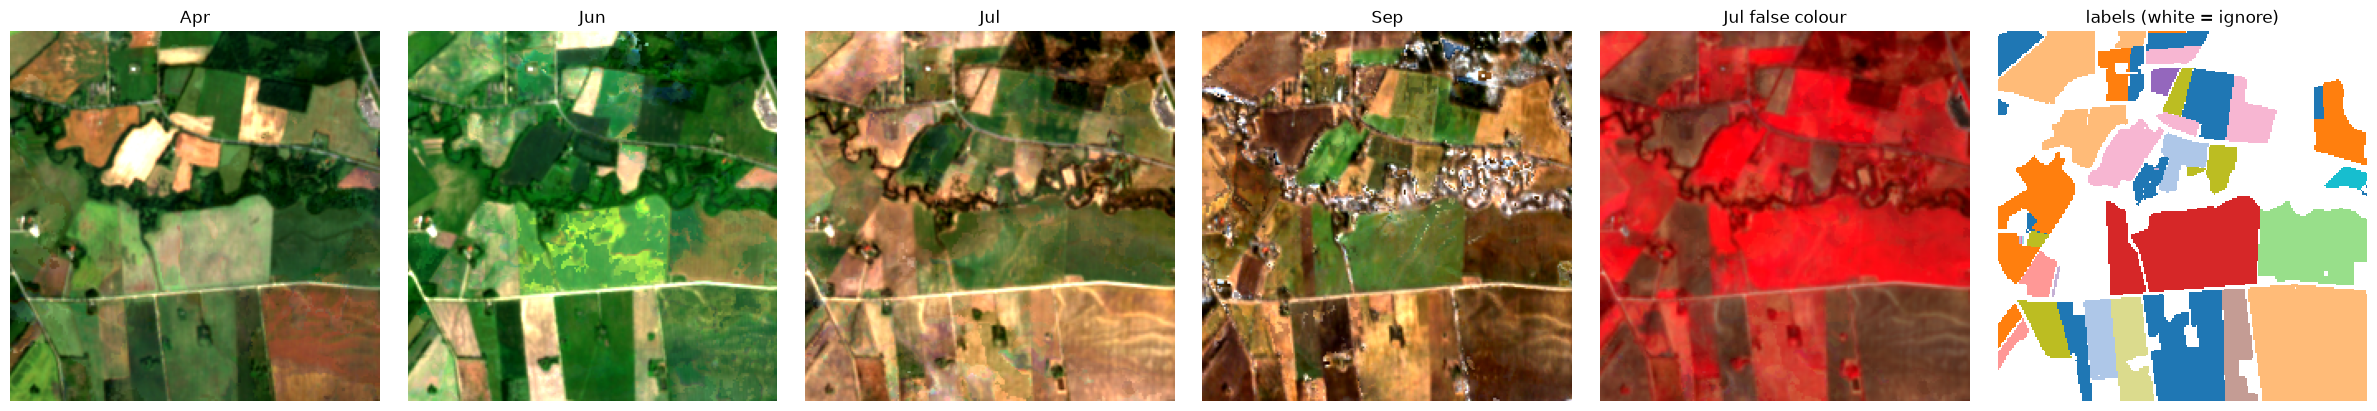

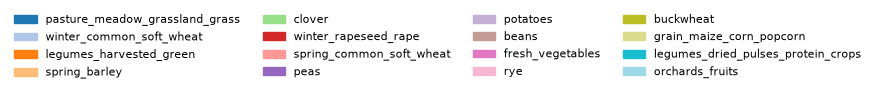

In [5]:
MONTHS = "Jan Feb Mar Apr May Jun Jul Aug Sep Oct Nov Dec".split()
cmap = plt.get_cmap("tab20", len(NAMES))

def composite(image, month, bands=("RED", "GREEN", "BLUE")):
    """(C, T, H, W) raw reflectance -> (H, W, 3) with a 2-98 % stretch."""
    b = [dm.bands.index(k) for k in bands]
    a = image[b, month].permute(1, 2, 0).numpy().astype(float)
    lo, hi = np.percentile(a, [2, 98])
    return np.clip((a - lo) / (hi - lo + 1e-6), 0, 1)

def show_mask(ax, mask, title):
    ax.imshow(np.ma.masked_less(np.asarray(mask), 0), cmap=cmap, vmin=-0.5, vmax=len(NAMES) - 0.5,
              interpolation="nearest")
    ax.set_title(title); ax.axis("off")

def legend(classes=None):
    classes = classes if classes is not None else range(len(NAMES))
    h = [plt.Rectangle((0, 0), 1, 1, color=cmap(k)) for k in classes]
    plt.figure(figsize=(8, 0.1)); plt.axis("off")
    plt.legend(h, [NAMES[k] for k in classes], ncol=4, loc="center", fontsize=8, frameon=False)

fig, axes = plt.subplots(1, 6, figsize=(24, 4))
for ax, m in zip(axes[:4], (3, 5, 6, 8)):
    ax.imshow(composite(s["image"], m)); ax.set_title(MONTHS[m]); ax.axis("off")
axes[4].imshow(composite(s["image"], 6, ("NIR_NARROW", "RED", "GREEN"))); axes[4].set_title("Jul false colour"); axes[4].axis("off")
show_mask(axes[5], s["mask"], "labels (white = ignore)")
plt.tight_layout()
legend(sorted(k for k in s["mask"].unique().tolist() if k >= 0))

## 4. The label budget

This part does not depend on the model. K parcels per class are drawn with a seed that depends only on (country, class, K, draw), so Prithvi gets **exactly the same parcels** as TerraMind at every budget. The mask is restricted to them before augmentation. The TerraMind notebook, section 4, shows the masks.

In [6]:
keep, report = draw_support(ROOT, pct=5, draw_seed=0)
print(f"5 %: {len(keep)} parcels; the first ids: {keep[:8].tolist()}")

K=5: 94 parcels; the first ids: [19992623, 19992624, 20091755, 20092771, 20092777, 20098221, 20106953, 20141473]


## 5. The model

The registry entry for Prithvi, as TerraTorch receives it:

In [7]:
spec = get_backbone(cfg["model"]["backbone"])
print("resolution group:", spec.resolution_group, "| uses date and location:", spec.uses_coords)
print("notes:", spec.notes)
print(json.dumps(spec.model_args(dm.bands, dm.n_timesteps), indent=1))

resolution group: token_grid | uses date and location: True
notes: 24 layers, 1024 dims, 16 x 16 patches, HLS six-band pretraining, date and location encodings
{
 "backbone": "prithvi_eo_v2_300_tl",
 "backbone_pretrained": true,
 "backbone_bands": [
  "BLUE",
  "GREEN",
  "RED",
  "NIR_NARROW",
  "SWIR_1",
  "SWIR_2"
 ],
 "backbone_num_frames": 12,
 "necks": [
  {
   "name": "SelectIndices",
   "indices": [
    5,
    11,
    17,
    23
   ]
  },
  {
   "name": "ReshapeTokensToImage",
   "remove_cls_token": true,
   "effective_time_dim": 12
  },
  {
   "name": "ChannelBottleneck",
   "out_channels": 768
  },
  {
   "name": "LearnedInterpolateToPyramidal"
  }
 ]
}


How it differs from TerraMind, stage by stage:

- **Native time.** `backbone_num_frames: 12`. The 3D patch embedding cuts each month into 16 x 16 patches (tubelet depth 1), so the ViT sees **12 x 196 = 2,352 tokens plus a class token**, with a 3D sine-cosine position encoding over (month, row, column). Attention runs *across* months as well as across space, so the encoder itself can relate June to August. TerraMind's wrapper only puts the months side by side after encoding.
- **`SelectIndices [5, 11, 17, 23]`** takes 4 of the 24 layers, evenly spaced.
- **`ReshapeTokensToImage`** drops the class token and folds the months into channels, giving **12 x 1024 = 12,288 channels** on a 14 x 14 grid.
- **`ChannelBottleneck` (768)** is a thesis neck (`src/gfm4agri/benchmark/necks.py`): a 1 x 1 convolution per level, with batch norm and GELU. Without it, the next layer, a transposed convolution in `LearnedInterpolateToPyramidal`, would need about **300 M parameters** for its first level alone. The projection also mixes the 12 months at each token position, so it is where the decoder first weighs dates.
- **`LearnedInterpolateToPyramidal` + UNet decoder + head** are the same as for TerraMind.

The cell below runs one batch through each stage. It runs the encoder a second time **without** the date and location inputs, to confirm they actually change the representation.

In [8]:
m = cfg["model"]
task = build_task(m["backbone"], num_classes=len(NAMES), class_names=NAMES, bands=dm.bands,
                  n_timesteps=dm.n_timesteps, ignore_index=dm.manifest["ignore_index"], lr=m["lr"],
                  weight_decay=m["weight_decay"], head_dropout=m["head_dropout"], loss=m["loss"])
model = task.model.to(DEVICE).eval()
vb = next(iter(dm.val_dataloader()))
xb = dm.aug(vb)["image"].to(DEVICE)
coords = {k: vb[k].to(DEVICE) for k in ("temporal_coords", "location_coords")}
with torch.no_grad(), torch.autocast(DEVICE, enabled=DEVICE == "cuda"):
    print("input            ", tuple(xb.shape), "(batch, bands, months, H, W)")
    feats = model.encoder(xb, **coords)
    print("encoder layers   ", len(feats), "x", tuple(feats[0].shape), "(batch, 1 + 12 x 196 tokens, 1024)")
    neck_in = feats
    for op in model.neck:
        neck_in = op(neck_in, image_size=xb.shape[-2:])
        print(f"after {type(op).__name__:28s}", [tuple(f.shape) for f in neck_in])
    dec = model.decoder([f.clone() for f in neck_in])
    print("decoder output   ", tuple(dec.shape))
    logits = model(xb, **coords).output
    print("logits           ", tuple(logits.shape), "(batch, classes, H, W)")
    plain = model.encoder(xb)
    rel = [float((a - b).norm() / a.norm()) for a, b in zip(feats, plain)]
print("relative change in layers 5, 11, 17, 23 when date and location are dropped:",
      [round(rel[i], 3) for i in (5, 11, 17, 23)])

input             (4, 6, 12, 224, 224) (batch, bands, months, H, W)


encoder layers    24 x (4, 2353, 1024) (batch, 1 + 12 x 196 tokens, 1024)
after SelectIndices                [(4, 2353, 1024), (4, 2353, 1024), (4, 2353, 1024), (4, 2353, 1024)]
after ReshapeTokensToImage         [(4, 12288, 14, 14), (4, 12288, 14, 14), (4, 12288, 14, 14), (4, 12288, 14, 14)]
after ChannelBottleneck            [(4, 768, 14, 14), (4, 768, 14, 14), (4, 768, 14, 14), (4, 768, 14, 14)]


after LearnedInterpolateToPyramidal [(4, 192, 56, 56), (4, 384, 28, 28), (4, 768, 14, 14), (4, 768, 7, 7)]
decoder output    (4, 64, 56, 56)


logits            (4, 20, 224, 224) (batch, classes, H, W)


relative change in layers 5, 11, 17, 23 when date and location are dropped: [0.055, 0.068, 0.113, 0.078]


Dropping the date and location encodings changes the deep features by roughly 5 to 11 %, so they are active and not silently ignored. Whether they *help* would take an ablation run: `--set model.backbone=prithvi_eo_v2_300` is the same model without them.

**Capacity.** The trainable part (bottleneck, pyramid, decoder and head) is much smaller than TerraMind's, even though the encoder is 14 times larger, because the bottleneck cuts the width before the expensive layers. That is the right direction, but it means the two models are not yet capacity-matched. Applying the same bottleneck to TerraMind is a one-line registry change, and it is needed before any comparison counts.

In [9]:
p = count_params(task)
table = pd.DataFrame({"Prithvi-EO-2.0 600M TL": p})
if TM_RESULTS.exists():
    table["TerraMind v1 large"] = pd.Series(json.loads(TM_RESULTS.read_text())["params"])
(table / 1e6).round(2).rename_axis("parameters, millions").loc[lambda t: t.sum(axis=1) > 0]

,Prithvi-EO-2.0 300M TL,TerraMind v1 small
"parameters, millions",,
encoder_total,303.89,22.46
neck_total,40.41,95.56
neck_trainable,40.41,95.56
decoder_total,12.87,53.79
decoder_trainable,12.87,53.79
trainable_total,53.28,149.35
all_total,357.17,171.82


## 6. Training

The script is the normal way to train:

```bash
poetry run python scripts/seg/train.py -c configs/seg/prithvi_eo_v2_600_tl_ee_pilot.yaml
```

The cell below loads that checkpoint, or trains here with the same recipe if there is none: cross-entropy on labelled pixels only, AdamW at lr 1e-4, 16-bit mixed precision, 40 epochs, keeping the lowest validation loss. The encoder is frozen. Prithvi is heavier than TerraMind: 2,352 tokens through 24 layers of width 1024 on every chip, every epoch. Training takes correspondingly longer, and caching the frozen features becomes worthwhile sooner.

In [10]:
TRAIN_HERE = not CKPT.exists()
if TRAIN_HERE:
    import lightning.pytorch as pl
    pl.seed_everything(cfg["seed"], workers=True)
    dm_train = EuroCropsSegDataModule(ROOT, m["backbone"], normalisation=d["normalisation"],
                                      batch_size=d["batch_size"], num_workers=d["num_workers"], augment=d["augment"])
    ckpt_cb = pl.callbacks.ModelCheckpoint(dirpath=CKPT.parent, monitor="val/loss", mode="min",
                                           filename="best-loss", save_weights_only=True)
    trainer = pl.Trainer(accelerator="auto", devices=1, precision=cfg["trainer"]["precision"],
                         max_epochs=cfg["trainer"]["max_epochs"], callbacks=[ckpt_cb],
                         logger=pl.loggers.CSVLogger(RUN_DIR, name="logs"), log_every_n_steps=1)
    trainer.fit(task, datamodule=dm_train)
state = torch.load(CKPT, map_location="cpu", weights_only=False)["state_dict"]
print(task.load_state_dict(state))
task = task.to(DEVICE).eval()
if (RUN_DIR / "results.json").exists():
    r = json.loads((RUN_DIR / "results.json").read_text())
    print(f"script run: fit {r['fit_seconds'] / 60:.1f} min, peak GPU {r['peak_gpu_gb']} GB")

<All keys matched successfully>
script run: fit 10.6 min, peak GPU 3.62 GB


## 7. Results

**Learning curves**, with TerraMind's validation macro F1 overlaid when its run exists. The same caveats apply as before: 8 training chips, 4 validation chips, a single seed.

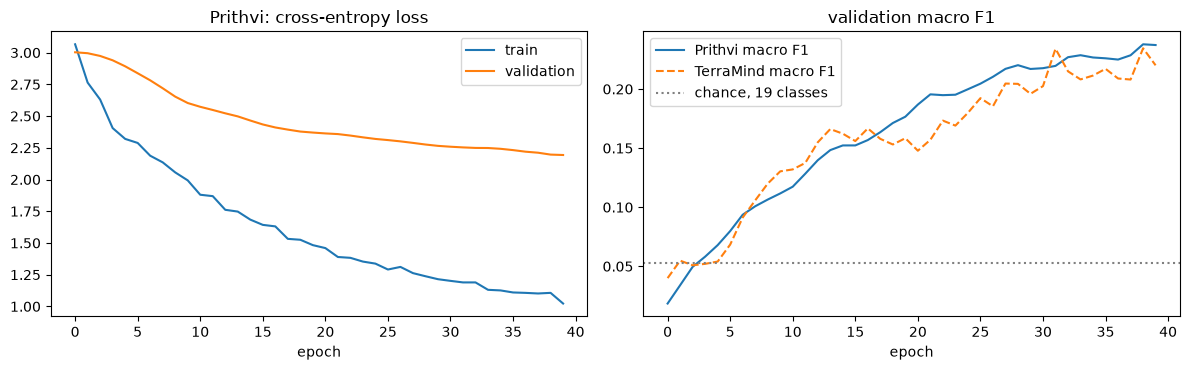

In [11]:
def history(run_dir):
    logs = sorted((run_dir / "logs").glob("version_*/metrics.csv"))
    return pd.read_csv(logs[-1]) if logs else None

h = history(RUN_DIR)
h_tm = history(TM_RESULTS.parent) if TM_RESULTS.exists() else None
if h is not None:
    tr = h.dropna(subset=["train/loss"]).groupby("epoch")["train/loss"].mean()
    va = h.dropna(subset=["val/loss"]).set_index("epoch")
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    axes[0].plot(tr.index, tr.values, label="train"); axes[0].plot(va.index, va["val/loss"], label="validation")
    axes[0].set_title("Prithvi: cross-entropy loss"); axes[0].legend()
    axes[1].plot(va.index, va["val/F1_Score"], label="Prithvi macro F1")
    if h_tm is not None:
        vt = h_tm.dropna(subset=["val/loss"]).set_index("epoch")
        axes[1].plot(vt.index, vt["val/F1_Score"], ls="--", label="TerraMind macro F1")
    axes[1].axhline(1 / 19, ls=":", c="grey", label="chance, 19 classes")
    axes[1].set_title("validation macro F1"); axes[1].legend()
    for a in axes: a.set_xlabel("epoch")
    plt.tight_layout()

**Prediction maps** for the four validation chips: July true colour, the reference, the prediction, and correct (green) against wrong (red) on labelled pixels. Prithvi works on the same 160 m token grid as TerraMind, so expect the same blocky boundaries. The decoder has to recover the 10 m parcel edges from coarse tokens.

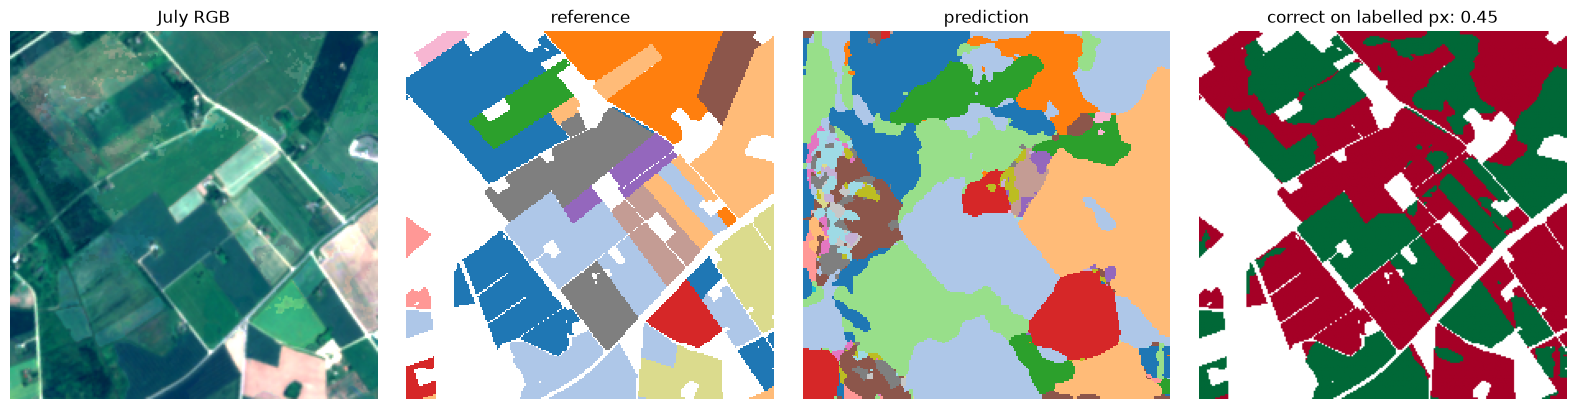

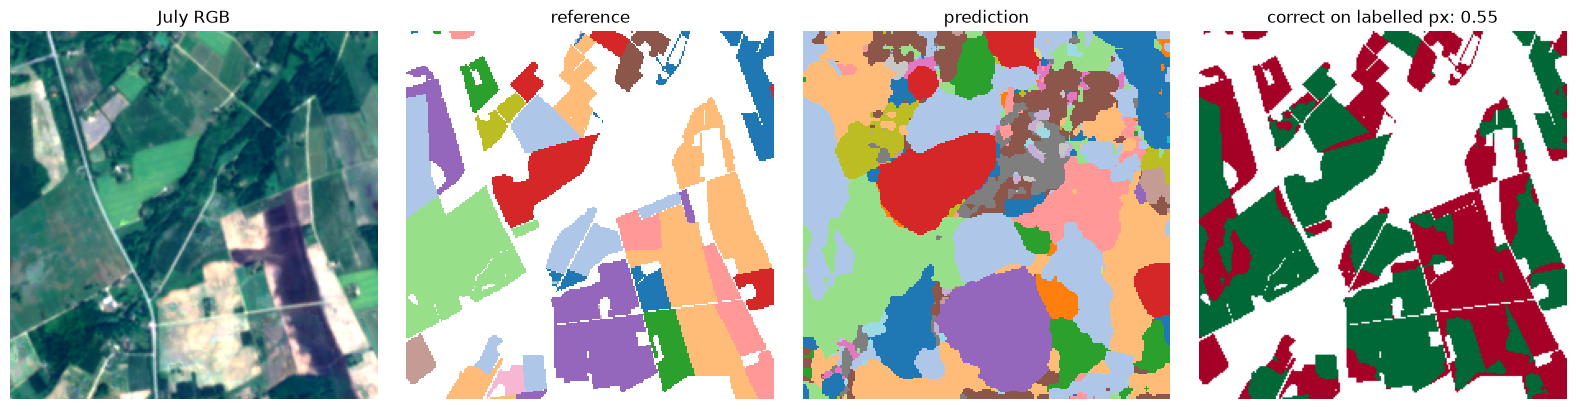

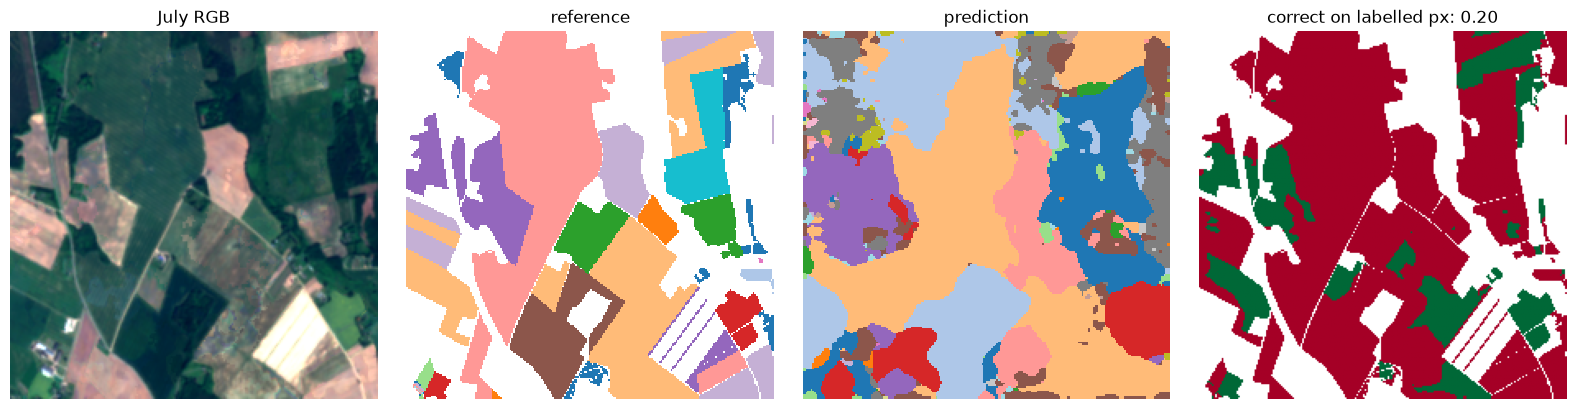

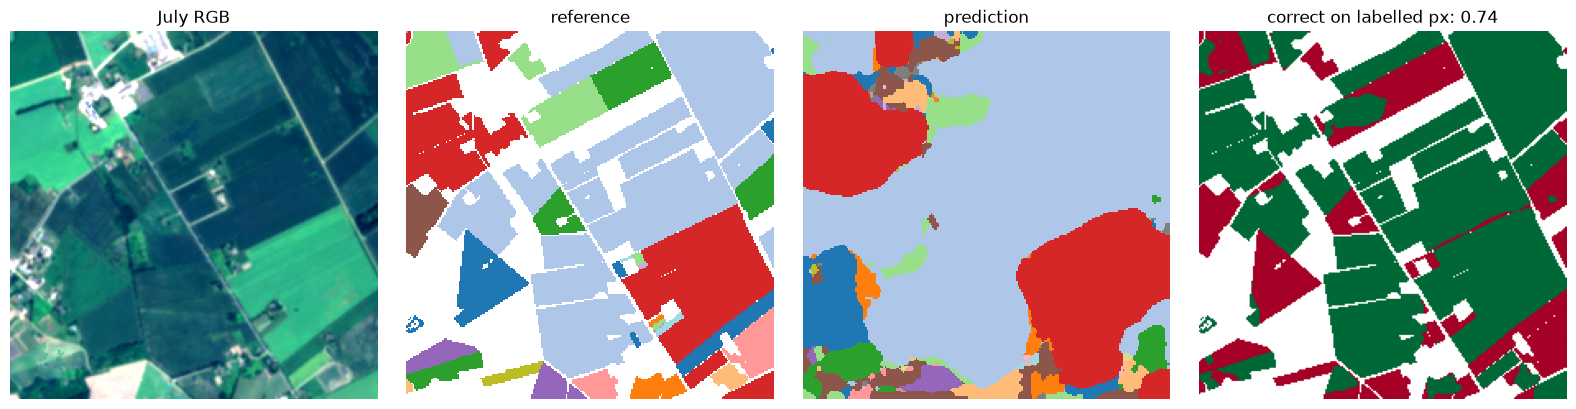

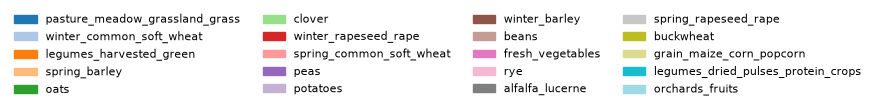

In [12]:
preds, masks, images = [], [], []
with torch.no_grad():
    for b in dm.val_dataloader():
        xv = dm.aug(b)["image"].to(DEVICE)
        kw = {k: b[k].to(DEVICE) for k in ("temporal_coords", "location_coords")}
        preds.append(task(xv, **kw).output.argmax(1).cpu()); masks.append(b["mask"]); images.append(b["image"])
preds, masks, images = torch.cat(preds), torch.cat(masks), torch.cat(images)
for i in range(len(preds)):
    lab = masks[i] >= 0
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(composite(images[i], 6)); axes[0].set_title("July RGB"); axes[0].axis("off")
    show_mask(axes[1], masks[i], "reference")
    show_mask(axes[2], preds[i], "prediction")
    axes[3].imshow(np.ma.masked_where(~lab.numpy(), (preds[i] == masks[i]).numpy()), cmap="RdYlGn", vmin=0, vmax=1)
    axes[3].set_title(f"correct on labelled px: {(preds[i][lab] == masks[i][lab]).float().mean():.2f}"); axes[3].axis("off")
    plt.tight_layout()
legend()

**Per-class scores and the comparison with TerraMind.** Per-class IoU on the validation chips, classes ordered by validation pixel count. TerraMind's values come from its `results.json`.

Before reading anything into the differences, remember what differs besides the encoder:
- the **bands**: 6 against 12;
- the **neck**: a 768-channel bottleneck against none;
- the **trainable capacity**: about 53 M against 149 M parameters.

On top of that there are only 4 validation chips and one seed. A difference here is a reason to run the controlled comparison, not a finding.

Prithvi: pixel accuracy 0.485 | macro F1 all 20 classes 0.237 | over the 19 present 0.250
TerraMind: pixel accuracy 0.537 | macro F1 all 20 classes 0.234


,class,val pixels,Prithvi IoU,Prithvi F1,TerraMind IoU
1,winter_common_soft_wheat,27551,0.524,0.687,0.747
3,spring_barley,18970,0.241,0.389,0.343
0,pasture_meadow_grassland_grass,13380,0.275,0.432,0.336
7,spring_common_soft_wheat,13031,0.018,0.036,0.018
6,winter_rapeseed_rape,12910,0.753,0.859,0.678
8,peas,9639,0.456,0.627,0.261
4,oats,7050,0.177,0.301,0.313
5,clover,6575,0.271,0.427,0.507
10,winter_barley,4801,0.001,0.001,0.045
2,legumes_harvested_green,4585,0.342,0.510,0.184


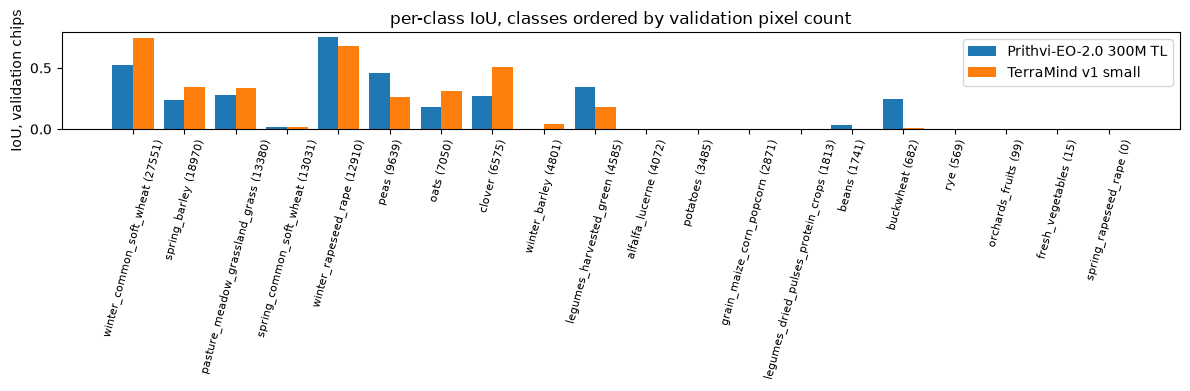

In [13]:
pv = preds[masks >= 0].numpy(); rv = masks[masks >= 0].numpy()
rows = []
tm = json.loads(TM_RESULTS.read_text())["test_metrics"] if TM_RESULTS.exists() else {}
for k, n in enumerate(NAMES):
    tp = np.sum((pv == k) & (rv == k)); fp = np.sum((pv == k) & (rv != k)); fn = np.sum((pv != k) & (rv == k))
    rows.append({"class": n, "val pixels": int((rv == k).sum()), "Prithvi IoU": tp / max(tp + fp + fn, 1),
                 "Prithvi F1": 2 * tp / max(2 * tp + fp + fn, 1), "TerraMind IoU": tm.get(f"test/IoU_{n}", np.nan)})
per_class = pd.DataFrame(rows).sort_values("val pixels", ascending=False)
present = per_class["val pixels"] > 0
print(f"Prithvi: pixel accuracy {np.mean(pv == rv):.3f} | macro F1 all 20 classes {per_class['Prithvi F1'].mean():.3f} "
      f"| over the {present.sum()} present {per_class.loc[present, 'Prithvi F1'].mean():.3f}")
if tm:
    print(f"TerraMind: pixel accuracy {tm['test/Pixel_Accuracy']:.3f} | macro F1 all 20 classes {tm['test/F1_Score']:.3f}")
xpos = np.arange(len(per_class))
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(xpos - 0.2, per_class["Prithvi IoU"], 0.4, label="Prithvi-EO-2.0 600M TL")
if tm:
    ax.bar(xpos + 0.2, per_class["TerraMind IoU"], 0.4, label="TerraMind v1 large")
ax.set_xticks(xpos, [f"{c} ({v})" for c, v in zip(per_class["class"], per_class["val pixels"])], rotation=75, fontsize=8)
ax.set_ylabel("IoU, validation chips"); ax.legend(); ax.set_title("per-class IoU, classes ordered by validation pixel count")
plt.tight_layout()
per_class.round(3)

## 8. What this establishes, and what comes next

**What the pilot shows.** Prithvi's validation macro F1 tracks TerraMind's closely through training, and both are still rising at epoch 40. On 4 validation chips the two are indistinguishable (about 0.24 each). The per-class wins are split: Prithvi is ahead on winter rapeseed, peas, legumes harvested green and buckwheat, and TerraMind on winter wheat, clover and oats. With one seed, 4 chips and the confounds listed above, this says the pipeline works for both models, not which one is better.

**Established.** A second GFM runs through the same pipeline from one new registry entry. The extras Prithvi needs, a band subset, native frames, and date and location inputs, are declared in the registry and supplied by the data module. None of that code is Prithvi-specific. The channel bottleneck keeps a 12-month, 1024-dimension encoder trainable on 16 GB.

**Before comparing the two models properly:**

1. **Match the necks.** Give TerraMind the same `ChannelBottleneck`, so the trainable capacity is comparable and reported per CLAUDE.md.
2. **Separate the band effect.** Run TerraMind on Prithvi's six bands as well, so the band set and the encoder are not confounded.
3. **Ablate the date and location encodings**: `prithvi_eo_v2_300` against `_tl`.
4. **Cache features.** Prithvi's frozen forward pass is the most expensive step. Caching it per chip and per D4 variant is what makes the K grid and repeated draws affordable.
5. **Use proper splits and seeds**: block cross-validation, held-out test blocks, several draws per K.

Prithvi is not among the four thesis GFMs (TerraMind, THOR, AlphaEarth, TESSERA). It is useful here as a well-documented, natively temporal reference, and as the model behind the published baseline for the multi-temporal crop rig.

```bash
poetry run python scripts/seg/train.py -c configs/seg/prithvi_eo_v2_600_tl_ee_pilot.yaml --set label_budget.mode=pct label_budget.pct=5
poetry run python scripts/seg/train.py -c configs/seg/prithvi_eo_v2_600_tl_ee_pilot.yaml --set model.backbone=prithvi_eo_v2_300 run_name=prithvi_no_coords
```